In [1]:
from __future__ import division, print_function, absolute_import

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import os
import importlib

from tensorflow import keras
from tensorflow.keras import layers
from scipy import signal

import generate_lorentz as gl
import generate_data as gd
import classify_data as cd
import efficient_data_generation as ed
import data_spy as ds
import sliding_window as sw
import train_model as tm

importlib.reload(cd)
importlib.reload(ed)
importlib.reload(ds)
importlib.reload(gl)
importlib.reload(sw)
importlib.reload(tm)

<module 'train_model' from '/home/gabriel/Seconcephalon/Projects/LEPRECHAUN/Analytis Laboratory/ML Peak Tracker/train_model.py'>

In [2]:
F = np.linspace(0,1,1024)
plt.rcParams['figure.figsize'] = 50, 5

[[0. 1. 1. 0. 1.]]


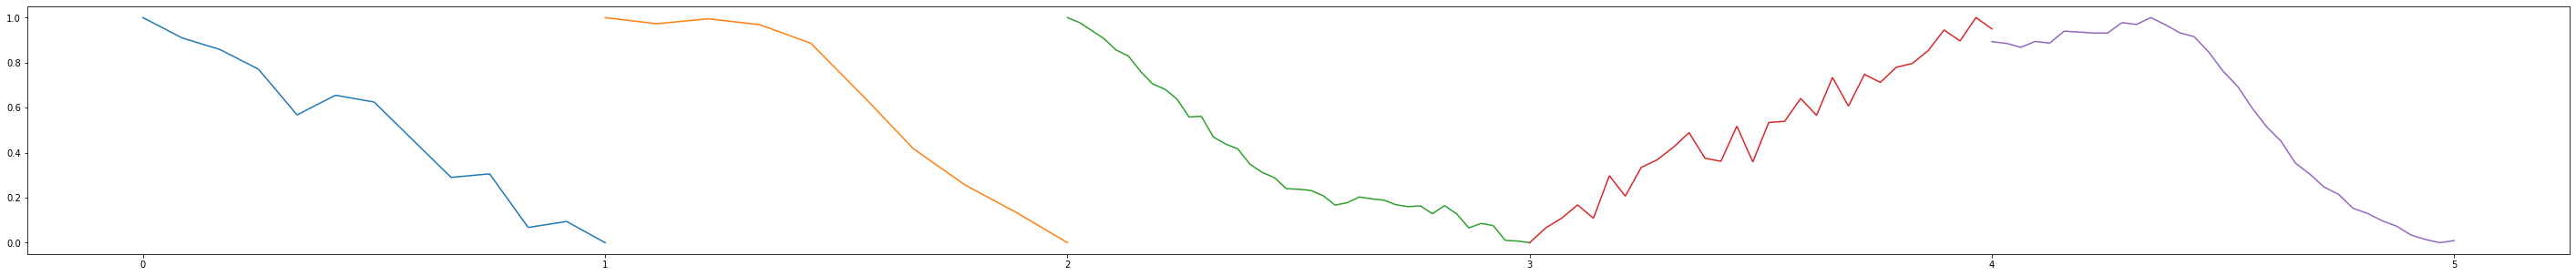

In [3]:
(label, data) = ed.make_single_data_set(5, noise=True, expansion=1)
print(np.transpose(label))
for i in range(0, len(label)):
    plt.plot(F + i, data[i])

In [2]:
# Make new training data
sing_train = ed.make_single_data_set(50000)

Generating Data: [########################################] 1000/1000

In [123]:
# Make new testing data
sing_test = ed.make_single_data_set(1000)

Generating Data: [########################################] 1000/1000

In [119]:
sing_model = keras.Sequential([
    keras.layers.Flatten(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    keras.layers.Dense(2, activation='softmax')
])

In [3]:
# Load existing model
sing_model = keras.models.load_model(os.path.join(os.getcwd(), 'models',  'wiggle_hidden_layer_1024'))
count_model = keras.models.load_model(os.path.join(os.getcwd(), 'models', 'class_hidden_layer_1024'))

In [121]:
# Compile model
sing_model.compile(optimizer='Adadelta',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [5]:
sing_model.fit(sing_train[1], sing_train[0], epochs=100)

Epoch 1/100
50000/50000 [==============================] - 6s 111us/sample - loss: 0.6653 - acc: 0.6255
Epoch 2/100
50000/50000 [==============================] - 5s 109us/sample - loss: 0.6235 - acc: 0.7352
Epoch 3/100
50000/50000 [==============================] - 5s 109us/sample - loss: 0.5987 - acc: 0.7816
Epoch 4/100
50000/50000 [==============================] - 5s 109us/sample - loss: 0.5770 - acc: 0.8189
Epoch 5/100
50000/50000 [==============================] - 5s 110us/sample - loss: 0.5575 - acc: 0.8477
Epoch 6/100
50000/50000 [==============================] - 5s 110us/sample - loss: 0.5402 - acc: 0.8680
Epoch 7/100
50000/50000 [==============================] - 6s 110us/sample - loss: 0.5248 - acc: 0.8826
Epoch 8/100
50000/50000 [==============================] - 5s 110us/sample - loss: 0.5113 - acc: 0.8924
Epoch 9/100
50000/50000 [==============================] - 5s 110us/sample - loss: 0.4994 - acc: 0.8993
Epoch 10/100
50000/50000 [==============================] - 6s 1

In [124]:
sing_loss, sing_acc = sing_model.evaluate(sing_test[1], sing_test[0])

1000/1000 [==============================] - 0s 316us/sample - loss: 0.3171 - acc: 0.9950


In [137]:
bg, l, f, v = gl.generate_normalized_data(max_num_lorentz=10)

In [138]:
regions = sw.slide_scale(sing_model, v, num_zooms=7, min_zoom=5, overlap=1/10, zoom_level=2, confidence_tolerance=0.95, merge_tolerance=0.4, compress=True)
def plot_region(i, color=None):
    min_f = int(regions[i][0])
    max_f = int(regions[i][1])
    if color is None:
        plt.plot(f[min_f:max_f], v[min_f:max_f])
    else:
        plt.plot(f[min_f:max_f], v[min_f:max_f], color=color)

7 detected Lorentzian regions
[[ 92. 476. 627. 707. 787. 812. 929.]
 [147. 553. 694. 774. 814. 928. 975.]]


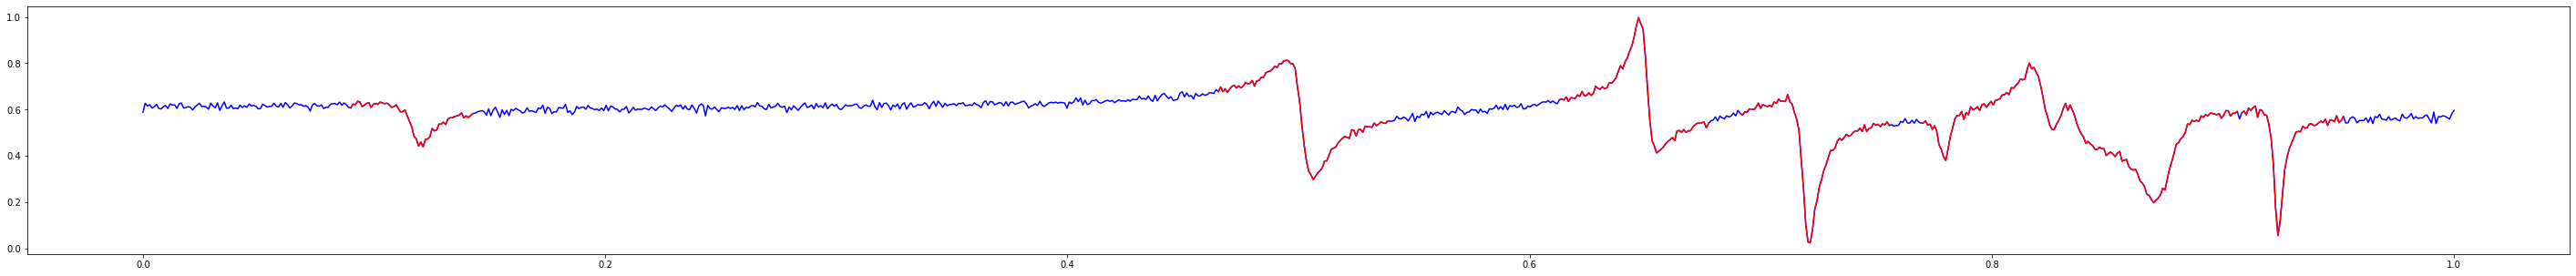

In [141]:
plt.plot(f, v, color='b')
for i in range(0, len(regions)):
    plot_region(i, color='r')
print(str(len(regions)) + ' detected Lorentzian regions')
print(np.transpose(regions))

In [105]:
sing_model.save(os.path.join(os.path.join(os.getcwd(), 'models'), 'quick_save_model'))